<a href="https://colab.research.google.com/github/huseyincenik/john_snow_labs/blob/main/generating_conll_files_from_pretrained_models/notebooks/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Training - Custom NER Model Training

This notebook trains a custom NER model using CoNLL format data.

**Google Drive Integration:**
- All files are saved to Google Drive
- Files are read from Google Drive
- Trained models are saved to Google Drive
- All code is embedded in this notebook (no external Python files required)

## Steps:
1. **Google Drive Connection** - Mount Google Drive
2. **Setup & License** - Spark NLP Healthcare license and environment setup
3. **CoNLL Dataset Loading** - Load CoNLL training data from Google Drive
4. **Train/Validation Split** - Split data into training and validation sets
5. **Model Training** - Train custom NER model
6. **Model Evaluation** - Evaluate model with precision, recall, F1-score metrics
7. **Model Saving** - Save trained model to Google Drive

**Requirements:**
- `data_prep.ipynb` notebook must be run first
- CoNLL file must exist at `data/conll/conll2003_text_file.conll` in Google Drive


## 1. Google Drive Connection


In [1]:
# Mount Google Drive
from google.colab import drive
import os
from pathlib import Path


# Mount Google Drive
drive.mount('/content/drive')

# Set project folder in Google Drive
PROJECT_FOLDER = '/content/drive/MyDrive/john_snow_labs_ner'
os.makedirs(PROJECT_FOLDER, exist_ok=True)

# Change working directory
os.chdir(PROJECT_FOLDER)

# Create folder structure
for folder in ['models/trained', 'ner_logs', 'data/processed']:
    os.makedirs(folder, exist_ok=True)

print(f"✅ Google Drive mounted")
print(f"✅ Project folder: {PROJECT_FOLDER}")
print(f"✅ Current directory: {os.getcwd()}")


Mounted at /content/drive
✅ Google Drive mounted
✅ Project folder: /content/drive/MyDrive/john_snow_labs_ner
✅ Current directory: /content/drive/MyDrive/john_snow_labs_ner


## 2. Setup & License Configuration


In [2]:
import json
import os

# Load license keys from Google Drive
license_path = f'{PROJECT_FOLDER}/spark_jsl.json'
if not os.path.exists(license_path):
    print("❌ License file not found!")
    print("Please run data_prep.ipynb first or upload spark_jsl.json to Google Drive")
    raise FileNotFoundError(f"License file not found at {license_path}")

with open(license_path) as f:
    license_keys = json.load(f)

# Set license keys as environment variables
locals().update(license_keys)
os.environ.update(license_keys)

print("✅ License keys loaded")
print(f"JSL Version: {license_keys.get('JSL_VERSION', 'N/A')}")
print(f"Public Version: {license_keys.get('PUBLIC_VERSION', 'N/A')}")


✅ License keys loaded
JSL Version: 6.1.1
Public Version: 6.1.3


In [3]:
# Install Java (required for Spark)
import subprocess

try:
    java_version = subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT, text=True)
    print(f"✅ Java is already installed: {java_version.split(chr(10))[0]}")

    if 'JAVA_HOME' not in os.environ:
        java_paths = [
            "/usr/lib/jvm/java-11-openjdk-amd64",
            "/usr/lib/jvm/java-8-openjdk-amd64",
            "/usr/lib/jvm/default-java"
        ]
        for path in java_paths:
            if os.path.exists(path):
                os.environ["JAVA_HOME"] = path
                print(f"✅ Set JAVA_HOME to: {path}")
                break
except Exception as e:
    print(f"Java check failed: {e}")
    print("Installing Java 11...")
    os.system('apt-get update -qq > /dev/null 2>&1')
    os.system('apt-get -y install -qq openjdk-11-jdk > /dev/null 2>&1')
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
    print("✅ Java 11 installation attempted")

# Check GPU availability
gpu_check = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
has_gpu = gpu_check.returncode == 0

if has_gpu:
    print("🚀 GPU detected! Installing PyTorch with CUDA support...")
    %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
else:
    print("Installing PyTorch (CPU version)...")
    %pip install -q torch torchvision torchaudio

# Install PySpark and Spark NLP
%pip install --upgrade -q pyspark==3.4.1 spark-nlp==$PUBLIC_VERSION

# Install Spark NLP Healthcare
%pip install --upgrade -q spark-nlp-jsl==$JSL_VERSION --extra-index-url https://pypi.johnsnowlabs.com/$SECRET

# Install additional dependencies
%pip install -q pandas numpy tqdm

print("✅ All libraries installed successfully!")
if has_gpu:
    print("✅ GPU-accelerated PyTorch installed")


Java check failed: [Errno 2] No such file or directory: 'java'
Installing Java 11...
✅ Java 11 installation attempted
🚀 GPU detected! Installing PyTorch with CUDA support...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 63.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 0.8.3 requires pyspark[connect]~=3.5.1, but you have pyspark 3.4.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 1.0 MB/s eta 0:00:00
✅ All libraries installed successfully!
✅ GPU-accelerated PyTorch installed


In [4]:
import sparknlp
import sparknlp_jsl
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import WordEmbeddingsModel
from sparknlp_jsl.annotator import (
    MedicalNerApproach,
    MedicalNerDLGraphChecker,
    MedicalNerModel
)
from sparknlp.training import CoNLL
from sparknlp_jsl.eval import NerDLMetrics
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        gpu_name = torch.cuda.get_device_name(0)
        print(f"🚀 GPU Detected: {gpu_name}")
    else:
        print("⚠️  No GPU detected. Using CPU mode.")
except ImportError:
    print("⚠️  PyTorch not available. GPU check skipped.")
    gpu_available = False

# Spark configuration
params = {
    "spark.driver.memory": "16G",
    "spark.kryoserializer.buffer.max": "2000M",
    "spark.driver.maxResultSize": "2000M",
    "spark.sql.execution.arrow.pyspark.enabled": "true",
    "spark.serializer": "org.apache.spark.serializer.KryoSerializer"
}

if gpu_available:
    params.update({
        "spark.jsl.settings.pretrained.cache_folder": f"{PROJECT_FOLDER}/cache_pretrained",
        "spark.jsl.settings.storage.cluster_tmp_dir": f"{PROJECT_FOLDER}/cache_pretrained",
        "spark.jsl.settings.annotator.gpu": "true"
    })
    print("✅ GPU acceleration enabled in Spark configuration")

# Start Spark session
try:
    print("Starting Spark session...")
    spark = sparknlp_jsl.start(license_keys['SECRET'], params=params)
    spark.sparkContext.setLogLevel("ERROR")

    print(f"✅ Spark NLP Version: {sparknlp.version()}")
    print(f"✅ Spark NLP JSL Version: {sparknlp_jsl.version()}")
    print("✅ Spark session initialized successfully")

except Exception as e:
    print(f"❌ Error starting Spark session: {e}")
    raise

spark


🚀 GPU Detected: Tesla T4
✅ GPU acceleration enabled in Spark configuration
Starting Spark session...
✅ Spark NLP Version: 6.1.3
✅ Spark NLP JSL Version: 6.1.1
✅ Spark session initialized successfully


## 3. Model Training Functions (Embedded)


In [5]:
# Model Training Functions - All code embedded in notebook

def load_embeddings(embeddings_model="embeddings_clinical"):
    """Load clinical word embeddings"""
    print(f"Loading {embeddings_model} embeddings...")
    clinical_embeddings = WordEmbeddingsModel.pretrained(
        embeddings_model, "en", "clinical/models"
    ).setInputCols(["sentence", "token"]).setOutputCol("embeddings")
    print("✅ Embeddings loaded successfully!")
    return clinical_embeddings

def load_conll_dataset(conll_path):
    """Load CoNLL format dataset"""
    print(f"Loading CoNLL dataset from {conll_path}...")
    data = CoNLL().readDataset(spark, conll_path)
    print(f"✅ Dataset loaded: {data.count()} sentences")
    return data

def split_dataset(data, train_ratio=0.8, seed=100):
    """Split dataset into train and validation sets"""
    train_data, validation_data = data.randomSplit(
        [train_ratio, 1 - train_ratio], seed=seed
    )
    print(f"✅ Train set: {train_data.count()} sentences")
    print(f"✅ Validation set: {validation_data.count()} sentences")
    return train_data, validation_data

def create_training_pipeline(clinical_embeddings,
                            max_epochs=20,
                            lr=0.003,
                            batch_size=8,
                            random_seed=0,
                            verbose=1,
                            test_dataset=None,
                            output_logs_path="./ner_logs",
                            validation_split=0.1,
                            use_best_model=True,
                            early_stopping_criterion=0.04,
                            early_stopping_patience=3):
    """Create training pipeline"""
    # Graph checker
    ner_dl_graph_checker = MedicalNerDLGraphChecker()\
        .setInputCols(["sentence", "token"])\
        .setLabelColumn("label")\
        .setEmbeddingsModel(clinical_embeddings)

    # NER Tagger
    ner_tagger = MedicalNerApproach()\
        .setInputCols(["sentence", "token", "embeddings"])\
        .setLabelColumn("label")\
        .setOutputCol("ner")\
        .setMaxEpochs(max_epochs)\
        .setLr(lr)\
        .setBatchSize(batch_size)\
        .setRandomSeed(random_seed)\
        .setVerbose(verbose)\
        .setEvaluationLogExtended(True)\
        .setEnableOutputLogs(True)\
        .setIncludeConfidence(True)\
        .setValidationSplit(validation_split)\
        .setUseBestModel(use_best_model)\
        .setEarlyStoppingCriterion(early_stopping_criterion)\
        .setEarlyStoppingPatience(early_stopping_patience)\
        .setOutputLogsPath(output_logs_path)

    if test_dataset:
        ner_tagger.setTestDataset(test_dataset)

    pipeline = Pipeline(stages=[
        clinical_embeddings,
        ner_dl_graph_checker,
        ner_tagger
    ])

    return pipeline

def evaluate_model(trained_model, test_data, clinical_embeddings, drop_o=True, case_sensitive=True):
    """Evaluate model performance"""
    print("Evaluating model...")
    pred_df = trained_model.stages[2].transform(
        clinical_embeddings.transform(test_data)
    )

    evaler = NerDLMetrics(mode="full_chunk")
    eval_result = evaler.computeMetricsFromDF(
        pred_df.select("label", "ner"),
        prediction_col="ner",
        label_col="label",
        drop_o=drop_o,
        case_sensitive=case_sensitive
    ).cache()

    # Format results
    eval_result_formatted = eval_result.withColumn(
        "precision", F.round(eval_result["precision"], 4)
    ).withColumn(
        "recall", F.round(eval_result["recall"], 4)
    ).withColumn(
        "f1", F.round(eval_result["f1"], 4)
    )

    print("\nEvaluation Results:")
    eval_result_formatted.show(100)

    # Calculate macro and micro averages
    print("\nMacro Average F1:")
    eval_result.selectExpr("avg(f1) as macro").show()
    print("\nMicro Average F1:")
    eval_result.selectExpr(
        "sum(f1*total) as sumprod", "sum(total) as sumtotal"
    ).selectExpr("sumprod/sumtotal as micro").show()

    return eval_result_formatted

def save_model(trained_model, model_path):
    """Save trained model"""
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    print(f"Saving model to {model_path}...")
    trained_model.stages[2].write().overwrite().save(str(model_path))
    print("✅ Model saved successfully!")

print("✅ Model training functions defined")


✅ Model training functions defined


## 4. Load CoNLL Dataset and Embeddings


In [6]:
# Load clinical embeddings
clinical_embeddings = load_embeddings("embeddings_clinical")

# Load CoNLL dataset from Google Drive
conll_path = f"{PROJECT_FOLDER}/data/conll/conll2003_text_file.conll"
if not os.path.exists(conll_path):
    print(f"❌ CoNLL file not found at {conll_path}")
    print("Please run data_prep.ipynb first to generate the CoNLL file")
    raise FileNotFoundError(f"CoNLL file not found at {conll_path}")

training_data = load_conll_dataset(conll_path)


Loading embeddings_clinical embeddings...
embeddings_clinical download started this may take some time.
Approximate size to download 1.6 GB
[OK!]
✅ Embeddings loaded successfully!
Loading CoNLL dataset from /content/drive/MyDrive/john_snow_labs_ner/data/conll/conll2003_text_file.conll...
✅ Dataset loaded: 25783 sentences


## 5. Split Dataset into Train and Validation


In [7]:
# Split dataset into train and validation
train_data, validation_data = split_dataset(training_data, train_ratio=0.8, seed=100)

# Save validation data as parquet for evaluation
test_data_path = f"{PROJECT_FOLDER}/data/processed/test_data.parquet"
Path(test_data_path).parent.mkdir(parents=True, exist_ok=True)
clinical_embeddings.transform(validation_data).write.mode("overwrite").parquet(test_data_path)
print(f"✅ Validation data saved to {test_data_path}")


✅ Train set: 20615 sentences
✅ Validation set: 5168 sentences
✅ Validation data saved to /content/drive/MyDrive/john_snow_labs_ner/data/processed/test_data.parquet


## 6. Model Training


In [8]:
# GPU optimization for batch size
try:
    import torch
    use_gpu = torch.cuda.is_available()
    if use_gpu:
        batch_size = 16
        print("🚀 GPU detected - using optimized batch size")
    else:
        batch_size = 8
        print("Using CPU mode - standard batch size")
except:
    batch_size = 8
    use_gpu = False

# Create training pipeline
output_logs_path = f"{PROJECT_FOLDER}/ner_logs"
training_pipeline = create_training_pipeline(
    clinical_embeddings=clinical_embeddings,
    max_epochs=35,
    lr=0.001,
    batch_size=batch_size,
    random_seed=0,
    verbose=1,
    test_dataset=test_data_path,
    output_logs_path=output_logs_path,
    validation_split=0.2,
    use_best_model=True,
    early_stopping_criterion=0.02,
    early_stopping_patience=6
)

print("✅ Training pipeline created")
print(f"Training parameters:")
print(f"  - Max epochs: 20")
print(f"  - Learning rate: 0.001")
print(f"  - Batch size: {batch_size} {'(GPU optimized)' if use_gpu else '(CPU)'}")
print(f"  - Validation split: 0.2")
print(f"  - Early stopping: Enabled")


🚀 GPU detected - using optimized batch size
✅ Training pipeline created
Training parameters:
  - Max epochs: 20
  - Learning rate: 0.001
  - Batch size: 16 (GPU optimized)
  - Validation split: 0.2
  - Early stopping: Enabled


In [9]:
# Start model training
try:
    import torch
    if torch.cuda.is_available():
        print("🚀 Starting model training with GPU acceleration...")
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("Starting model training on CPU... This may take several minutes...")
except:
    print("Starting model training... This may take several minutes...")

trained_model = training_pipeline.fit(train_data)

print("\n✅ Model training completed!")
print(f"\nTraining logs saved to {output_logs_path}/")


🚀 Starting model training with GPU acceleration...
   GPU: Tesla T4

✅ Model training completed!

Training logs saved to /content/drive/MyDrive/john_snow_labs_ner/ner_logs/


In [10]:
# Evaluate model performance
eval_results = evaluate_model(trained_model, validation_data, clinical_embeddings,
                              drop_o=True, case_sensitive=True)

print("\n✅ Evaluation completed!")


Evaluating model...

Evaluation Results:
+----------+------+-----+-----+------+---------+------+------+
|    entity|    tp|   fp|   fn| total|precision|recall|    f1|
+----------+------+-----+-----+------+---------+------+------+
|   CONTACT|   0.0|  0.0|  2.0|   2.0|      0.0|   0.0|   0.0|
|      NAME|  27.0|  3.0|  6.0|  33.0|      0.9|0.8182|0.8571|
|   PROBLEM|3337.0|218.0|285.0|3622.0|   0.9387|0.9213|0.9299|
|      DATE| 170.0|  8.0|  6.0| 176.0|   0.9551|0.9659|0.9605|
|        ID|   5.0|  1.0|  1.0|   6.0|   0.8333|0.8333|0.8333|
|  LOCATION|  55.0| 27.0|  8.0|  63.0|   0.6707| 0.873|0.7586|
| TREATMENT|2401.0|258.0|226.0|2627.0|    0.903| 0.914|0.9084|
|      TEST|1023.0|122.0|107.0|1130.0|   0.8934|0.9053|0.8993|
|PROFESSION|   4.0|  1.0|  8.0|  12.0|      0.8|0.3333|0.4706|
|       AGE|  53.0|  6.0|  3.0|  56.0|   0.8983|0.9464|0.9217|
+----------+------+-----+-----+------+---------+------+------+


Macro Average F1:
+------------------+
|             macro|
+--------------

## 6.1 View Training Logs

View the training logs to see the training progress and metrics.

In [11]:
# View training logs
import glob

log_files = glob.glob(f"{PROJECT_FOLDER}/ner_logs/MedicalNerApproach*")
if log_files:
    latest_log = max(log_files, key=os.path.getctime)
    print(f"Latest training log: {latest_log}\n")
    with open(latest_log, 'r') as f:
        print(f.read())
else:
    print("No training logs found.")

Latest training log: /content/drive/MyDrive/john_snow_labs_ner/ner_logs/MedicalNerApproach_efc523690338.log

Name of the selected graph: medical-ner-dl/blstm_100_200_128_100.pb
Training started - total epochs: 35 - lr: 0.001 - batch size: 16 - labels: 20 - chars: 87 - training examples: 20615


Epoch 1/35 started, lr: 0.001, dataset size: 20615


Epoch 1/35 - 114.94s - loss: 5841.5903 - avg training loss: 5.671447 - batches: 1030
Quality on validation dataset (20.0%), validation examples = 4123
time to finish evaluation: 21.05s
Total validation loss: 525.5264	Avg validation loss: 1.9982
label	 tp	 fp	 fn	 prec	 rec	 f1
I-NAME	 0	 0	 12	 0.0	 0.0	 0.0
I-TREATMENT	 2459	 718	 396	 0.77400064	 0.861296	 0.8153184
B-DATE	 100	 3	 37	 0.9708738	 0.729927	 0.8333333
I-DATE	 25	 0	 28	 1.0	 0.4716981	 0.64102566
I-LOCATION	 6	 0	 28	 1.0	 0.1764706	 0.29999998
I-PROBLEM	 4236	 574	 814	 0.8806653	 0.8388119	 0.8592292
I-PROFESSION	 0	 0	 11	 0.0	 0.0	 0.0
B-NAME	 6	 0	 20	 1.0	 0.23076923	 0.

## 6.2 Evaluate Model Performance

Evaluate the trained model on the test set using precision, recall, and F1-score metrics.

In [12]:
# Evaluate model performance
eval_results = evaluate_model(trained_model, validation_data, clinical_embeddings,
                              drop_o=True, case_sensitive=True)

print("\n✅ Model evaluation completed!")

Evaluating model...

Evaluation Results:
+----------+------+-----+-----+------+---------+------+------+
|    entity|    tp|   fp|   fn| total|precision|recall|    f1|
+----------+------+-----+-----+------+---------+------+------+
|   CONTACT|   0.0|  0.0|  2.0|   2.0|      0.0|   0.0|   0.0|
|      NAME|  27.0|  3.0|  6.0|  33.0|      0.9|0.8182|0.8571|
|   PROBLEM|3337.0|218.0|285.0|3622.0|   0.9387|0.9213|0.9299|
|      DATE| 170.0|  8.0|  6.0| 176.0|   0.9551|0.9659|0.9605|
|        ID|   5.0|  1.0|  1.0|   6.0|   0.8333|0.8333|0.8333|
|  LOCATION|  55.0| 27.0|  8.0|  63.0|   0.6707| 0.873|0.7586|
| TREATMENT|2401.0|258.0|226.0|2627.0|    0.903| 0.914|0.9084|
|      TEST|1023.0|122.0|107.0|1130.0|   0.8934|0.9053|0.8993|
|PROFESSION|   4.0|  1.0|  8.0|  12.0|      0.8|0.3333|0.4706|
|       AGE|  53.0|  6.0|  3.0|  56.0|   0.8983|0.9464|0.9217|
+----------+------+-----+-----+------+---------+------+------+


Macro Average F1:
+------------------+
|             macro|
+--------------

## 6.3 Save Trained Model

Save the trained model for future use.

In [13]:
# Save model
model_path = f"{PROJECT_FOLDER}/models/trained/custom_ner_model"
save_model(trained_model, model_path)

print(f"\n✅ Model saved to {model_path}")

Saving model to /content/drive/MyDrive/john_snow_labs_ner/models/trained/custom_ner_model...
✅ Model saved successfully!

✅ Model saved to /content/drive/MyDrive/john_snow_labs_ner/models/trained/custom_ner_model


# Section 7: Resume Training

This section demonstrates how to resume training on additional data. This is useful when:
- You want to continue training on new data from the same taxonomy
- You want to fine-tune a model trained on a different dataset

## 7.1 Resume Training on Same Taxonomy

Load a saved model and continue training on additional data from the same taxonomy.

In [14]:
# Split validation data for resume training demonstration
(validation_data_1, validation_data_2) = validation_data.randomSplit([0.5, 0.5], seed=100)

# Save validation data as parquet for easy testing
validation_data_1_path = f"{PROJECT_FOLDER}/data/processed/validation_1.parquet"
validation_data_2_path = f"{PROJECT_FOLDER}/data/processed/validation_2.parquet"

Path(validation_data_1_path).parent.mkdir(parents=True, exist_ok=True)
Path(validation_data_2_path).parent.mkdir(parents=True, exist_ok=True)

clinical_embeddings.transform(validation_data_1).write.mode("overwrite").parquet(validation_data_1_path)
clinical_embeddings.transform(validation_data_2).write.mode("overwrite").parquet(validation_data_2_path)

print(f"✅ Validation data split and saved")
print(f"  - validation_data_1: {validation_data_1.count()} sentences")
print(f"  - validation_data_2: {validation_data_2.count()} sentences")

✅ Validation data split and saved
  - validation_data_1: 2542 sentences
  - validation_data_2: 2626 sentences


In [15]:
# Create resume training pipeline with pretrained model
# Load the previously trained model
model_path = f"{PROJECT_FOLDER}/models/trained/custom_ner_model"

# Create pipeline that loads the previously trained model
output_logs_path_resume = f"{PROJECT_FOLDER}/ner_logs_resume"
os.makedirs(output_logs_path_resume, exist_ok=True)

# Graph checker
resume_ner_dl_graph_checker = MedicalNerDLGraphChecker()\
    .setInputCols(["sentence", "token"])\
    .setLabelColumn("label")\
    .setEmbeddingsModel(clinical_embeddings)

# NER Tagger with pretrained model
resume_ner_tagger = MedicalNerApproach()\
    .setInputCols(["sentence", "token", "embeddings"])\
    .setLabelColumn("label")\
    .setOutputCol("ner")\
    .setMaxEpochs(2)\
    .setLr(0.003)\
    .setBatchSize(batch_size)\
    .setRandomSeed(0)\
    .setVerbose(1)\
    .setEvaluationLogExtended(True)\
    .setEnableOutputLogs(True)\
    .setIncludeConfidence(True)\
    .setValidationSplit(0.1)\
    .setUseBestModel(True)\
    .setEarlyStoppingCriterion(0.04)\
    .setEarlyStoppingPatience(3)\
    .setOutputLogsPath(output_logs_path_resume)\
    .setPretrainedModelPath(model_path)  # Load previously trained model

resume_ner_tagger.setTestDataset(validation_data_2_path)

resume_pipeline = Pipeline(stages=[
    clinical_embeddings,
    resume_ner_dl_graph_checker,
    resume_ner_tagger
])

print("✅ Resume training pipeline created")
print(f"  - Pretrained model: {model_path}")
print(f"  - Additional training epochs: 2")

✅ Resume training pipeline created
  - Pretrained model: /content/drive/MyDrive/john_snow_labs_ner/models/trained/custom_ner_model
  - Additional training epochs: 2


In [16]:
# Resume training on additional data
print("Resuming training on additional data...")
resume_trained_model = resume_pipeline.fit(validation_data_1)

print("\n✅ Resume training completed!")

Resuming training on additional data...

✅ Resume training completed!


## 7.2 Evaluate Resumed Model

Evaluate the model after resume training to see if performance improved.

In [17]:
# Evaluate resumed model
resume_eval_results = evaluate_model(resume_trained_model, validation_data_2, clinical_embeddings,
                                     drop_o=True, case_sensitive=True)

print("\n✅ Resume model evaluation completed!")

Evaluating model...

Evaluation Results:
+----------+------+-----+-----+------+---------+------+------+
|    entity|    tp|   fp|   fn| total|precision|recall|    f1|
+----------+------+-----+-----+------+---------+------+------+
|   CONTACT|   0.0|  0.0|  2.0|   2.0|      0.0|   0.0|   0.0|
|      NAME|   6.0|  0.0| 14.0|  20.0|      1.0|   0.3|0.4615|
|   PROBLEM|1530.0|173.0|299.0|1829.0|   0.8984|0.8365|0.8664|
|      DATE|  74.0|  3.0|  6.0|  80.0|    0.961| 0.925|0.9427|
|        ID|   0.0|  0.0|  5.0|   5.0|      0.0|   0.0|   0.0|
|  LOCATION|   2.0|  3.0| 31.0|  33.0|      0.4|0.0606|0.1053|
| TREATMENT|1145.0|411.0|129.0|1274.0|   0.7359|0.8987|0.8092|
|      TEST| 437.0| 55.0|163.0| 600.0|   0.8882|0.7283|0.8004|
|PROFESSION|   0.0|  0.0|  4.0|   4.0|      0.0|   0.0|   0.0|
|       AGE|  25.0|  0.0|  2.0|  27.0|      1.0|0.9259|0.9615|
+----------+------+-----+-----+------+---------+------+------+


Macro Average F1:
+-------------------+
|              macro|
+------------

## 7.3 Train Using Different Pretrained Model

You can also train a model starting from a different pretrained model (e.g., ner_jsl) and fine-tune it on your data.

In [18]:
# Load a different pretrained model (e.g., ner_jsl)
jsl_ner = MedicalNerModel.pretrained('ner_jsl', 'en', 'clinical/models')
print(f"\n✅ Loaded ner_jsl model")
print(f"Entity classes in ner_jsl: {len(jsl_ner.getClasses())} classes")
print(f"Sample classes: {jsl_ner.getClasses()[:10]}")

# Note: To use this model as a starting point, you would need to:
# 1. Get the model path: jsl_ner.getModelPath()
# 2. Use it in create_training_pipeline with pretrained_model_path
# 3. Set overrideExistingTags=True if entity tags don't align

ner_jsl download started this may take some time.
Approximate size to download 14.5 MB
[OK!]

✅ Loaded ner_jsl model
Entity classes in ner_jsl: 155 classes
Sample classes: ['O', 'B-Injury_or_Poisoning', 'B-Direction', 'B-Test', 'I-Route', 'B-Admission_Discharge', 'B-Death_Entity', 'I-Oxygen_Therapy', 'B-Relationship_Status', 'I-Drug_BrandName']


# Section 8: Bonus - Visualization, Comparison & Error Analysis

This section includes bonus features for advanced analysis:
1. **Visualize Predictions** - Visualize custom NER model predictions on sample texts
2. **Performance Comparison** - Compare model performance before and after fine-tuning
3. **Error Analysis** - Identify common mistakes and misclassifications

## 8.1 Visualization Module

This module provides functions to visualize NER predictions and analyze model performance.


In [19]:
"""
Visualization and Analysis Module
Provides functions for visualizing NER predictions, comparing models, and error analysis
"""

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
from sparknlp_jsl.annotator import MedicalNerModel
from sparknlp.base import DocumentAssembler
from sparknlp.annotator import SentenceDetector, Tokenizer
from sparknlp_jsl.annotator import NerConverter
from pyspark.sql import functions as F
from pyspark.ml import Pipeline

# Set style for better visualizations
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")


class NERVisualizer:
    """Visualize NER predictions and analyze model performance"""

    def __init__(self, spark):
        """
        Initialize NER Visualizer

        Args:
            spark: SparkSession instance
        """
        self.spark = spark

    def visualize_predictions(
        self,
        model,
        texts: list,
        embeddings_model,
        max_texts: int = 5,
        save_path: str = None,
    ):
        """
        Visualize NER predictions on sample texts using Spark NLP Display

        Args:
            model: Trained MedicalNerModel
            texts: List of text strings to visualize
            embeddings_model: Word embeddings model
            max_texts: Maximum number of texts to visualize
            save_path: Optional path to save visualization
        """
        print(
            f"Visualizing predictions on {min(len(texts), max_texts)} sample texts..."
        )

        # Remove duplicate texts while preserving order
        seen = set()
        unique_texts = []
        for text in texts:
            if text not in seen:
                seen.add(text)
                unique_texts.append(text)
        texts = unique_texts

        # Limit number of texts
        texts = texts[:max_texts]

        # Create Spark DataFrame with index to track original texts
        text_df = pd.DataFrame({"text": texts})
        text_df["text_id"] = range(len(texts))
        spark_df = self.spark.createDataFrame(text_df)

        # Create pipeline for visualization
        document_assembler = (
            DocumentAssembler()
            .setInputCol("text")
            .setOutputCol("document")
            .setCleanupMode("shrink")
        )

        sentence_detector = (
            SentenceDetector()
            .setInputCols(["document"])
            .setOutputCol("sentence")
            .setExplodeSentences(True)
        )

        tokenizer = Tokenizer().setInputCols(["sentence"]).setOutputCol("token")

        ner_converter = (
            NerConverter()
            .setInputCols(["document", "token", "ner"])
            .setOutputCol("entities")
        )

        pipeline = Pipeline(
            stages=[
                document_assembler,
                sentence_detector,
                tokenizer,
                embeddings_model,
                model,
                ner_converter,
            ]
        )

        # Transform data
        result = pipeline.fit(spark_df).transform(spark_df)

        # Group results by original text (text_id) to avoid duplicates
        # Since explodeSentences creates multiple rows per text, we need to group them
        from pyspark.sql import functions as F

        # Collect all results and group by original text
        all_results = result.select("text_id", "text", "entities").collect()

        # Group by text_id to combine entities from all sentences of the same text
        text_results = {}
        for row in all_results:
            text_id = row.text_id
            text_content = row.text
            entities = row.entities if row.entities else []

            if text_id not in text_results:
                text_results[text_id] = {
                    "text": text_content,
                    "entities": []
                }

            # Add entities from this row (avoid duplicates)
            if entities:
                for entity in entities:
                    # Check if entity already exists (same text and position)
                    entity_key = (entity.result, entity.begin, entity.end)
                    existing_keys = [(e.result, e.begin, e.end) for e in text_results[text_id]["entities"]]
                    if entity_key not in existing_keys:
                        text_results[text_id]["entities"].append(entity)

        # Display using Spark NLP Display
        try:
            from sparknlp_display import NerVisualizer

            for text_idx, (text_id, data) in enumerate(sorted(text_results.items())):
                print(f"\n{'='*80}")
                print(f"Text {text_idx + 1}:")
                print(f"{'='*80}")
                print(data["text"])
                print(f"\nEntities found:")

                # Extract entities
                entities = data["entities"]
                if entities:
                    for entity in entities:
                        print(
                            f"  - {entity.result}: {entity.metadata.get('entity', 'N/A')} "
                            f"(confidence: {entity.metadata.get('confidence', 'N/A')})"
                        )
                else:
                    print("  No entities found")

                # Try to use NerVisualizer if available
                try:
                    # Create a temporary row-like object for visualization
                    class TempRow:
                        def __init__(self, entities):
                            self.entities = entities

                    visualizer = NerVisualizer()
                    temp_row = TempRow(entities)
                    visualizer.display(
                        temp_row,
                        label_col="entities",
                        document_col="text",
                    )
                except:
                    print("  (Visual display not available)")
        except ImportError:
            print("Spark NLP Display not available. Showing text output only.")
            for text_idx, (text_id, data) in enumerate(sorted(text_results.items())):
                print(f"\n{'='*80}")
                print(f"Text {text_idx + 1}:")
                print(f"{'='*80}")
                print(data["text"])
                if data["entities"]:
                    for entity in data["entities"]:
                        print(
                            f"  - {entity.result}: {entity.metadata.get('entity', 'N/A')}"
                        )

    def compare_models(
        self,
        model1,
        model1_name: str,
        model2,
        model2_name: str,
        test_data,
        embeddings_model,
    ):
        """
        Compare performance of two models

        Args:
            model1: First model (e.g., pretrained)
            model1_name: Name of first model
            model2: Second model (e.g., fine-tuned)
            model2_name: Name of second model
            test_data: Test dataset
            embeddings_model: Word embeddings model
        """
        from sparknlp_jsl.eval import NerDLMetrics

        print(f"Comparing {model1_name} vs {model2_name}...")

        results = {}

        # Evaluate model 1
        print(f"\nEvaluating {model1_name}...")
        pipeline1 = Pipeline(stages=[embeddings_model, model1])
        pred1 = pipeline1.fit(test_data).transform(
            embeddings_model.transform(test_data)
        )

        evaler = NerDLMetrics(mode="full_chunk")
        eval1 = evaler.computeMetricsFromDF(
            pred1.select("label", "ner"),
            prediction_col="ner",
            label_col="label",
            drop_o=True,
            case_sensitive=True,
        )

        results[model1_name] = eval1

        # Evaluate model 2
        print(f"\nEvaluating {model2_name}...")
        pipeline2 = Pipeline(stages=[embeddings_model, model2])
        pred2 = pipeline2.fit(test_data).transform(
            embeddings_model.transform(test_data)
        )

        eval2 = evaler.computeMetricsFromDF(
            pred2.select("label", "ner"),
            prediction_col="ner",
            label_col="label",
            drop_o=True,
            case_sensitive=True,
        )

        results[model2_name] = eval2

        # Create comparison DataFrame
        comparison_data = []
        for model_name, eval_df in results.items():
            for row in eval_df.collect():
                comparison_data.append(
                    {
                        "Model": model_name,
                        "Entity": row.entity,
                        "Precision": row.precision,
                        "Recall": row.recall,
                        "F1": row.f1,
                        "TP": row.tp,
                        "FP": row.fp,
                        "FN": row.fn,
                    }
                )

        comparison_df = pd.DataFrame(comparison_data)

        # Create visualization
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(
            f"Model Comparison: {model1_name} vs {model2_name}",
            fontsize=16,
            fontweight="bold",
        )

        # 1. F1 Score Comparison
        ax1 = axes[0, 0]
        pivot_f1 = comparison_df.pivot(index="Entity", columns="Model", values="F1")
        pivot_f1.plot(kind="bar", ax=ax1, width=0.8)
        ax1.set_title("F1 Score Comparison by Entity", fontweight="bold")
        ax1.set_ylabel("F1 Score")
        ax1.set_xlabel("Entity Type")
        ax1.legend(title="Model")
        ax1.grid(axis="y", alpha=0.3)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

        # 2. Precision Comparison
        ax2 = axes[0, 1]
        pivot_prec = comparison_df.pivot(
            index="Entity", columns="Model", values="Precision"
        )
        pivot_prec.plot(kind="bar", ax=ax2, width=0.8, color=["#3498db", "#e74c3c"])
        ax2.set_title("Precision Comparison by Entity", fontweight="bold")
        ax2.set_ylabel("Precision")
        ax2.set_xlabel("Entity Type")
        ax2.legend(title="Model")
        ax2.grid(axis="y", alpha=0.3)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")

        # 3. Recall Comparison
        ax3 = axes[1, 0]
        pivot_rec = comparison_df.pivot(
            index="Entity", columns="Model", values="Recall"
        )
        pivot_rec.plot(kind="bar", ax=ax3, width=0.8, color=["#2ecc71", "#f39c12"])
        ax3.set_title("Recall Comparison by Entity", fontweight="bold")
        ax3.set_ylabel("Recall")
        ax3.set_xlabel("Entity Type")
        ax3.legend(title="Model")
        ax3.grid(axis="y", alpha=0.3)
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")

        # 4. Overall Metrics
        ax4 = axes[1, 1]
        macro_metrics = []
        for model_name in [model1_name, model2_name]:
            model_data = comparison_df[comparison_df["Model"] == model_name]
            macro_metrics.append(
                {
                    "Model": model_name,
                    "Macro F1": model_data["F1"].mean(),
                    "Macro Precision": model_data["Precision"].mean(),
                    "Macro Recall": model_data["Recall"].mean(),
                }
            )

        macro_df = pd.DataFrame(macro_metrics)
        macro_df.set_index("Model").plot(kind="bar", ax=ax4, width=0.8)
        ax4.set_title("Overall Macro-Average Metrics", fontweight="bold")
        ax4.set_ylabel("Score")
        ax4.set_xlabel("Model")
        ax4.legend(title="Metric")
        ax4.grid(axis="y", alpha=0.3)
        plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0)

        plt.tight_layout()
        plt.show()

        # Print summary
        print(f"\n{'='*80}")
        print("COMPARISON SUMMARY")
        print(f"{'='*80}")
        print(f"\n{model1_name}:")
        print(
            f"  Macro F1: {comparison_df[comparison_df['Model']==model1_name]['F1'].mean():.4f}"
        )
        print(
            f"  Macro Precision: {comparison_df[comparison_df['Model']==model1_name]['Precision'].mean():.4f}"
        )
        print(
            f"  Macro Recall: {comparison_df[comparison_df['Model']==model1_name]['Recall'].mean():.4f}"
        )

        print(f"\n{model2_name}:")
        print(
            f"  Macro F1: {comparison_df[comparison_df['Model']==model2_name]['F1'].mean():.4f}"
        )
        print(
            f"  Macro Precision: {comparison_df[comparison_df['Model']==model2_name]['Precision'].mean():.4f}"
        )
        print(
            f"  Macro Recall: {comparison_df[comparison_df['Model']==model2_name]['Recall'].mean():.4f}"
        )

        return comparison_df

    def error_analysis(self, model, test_data, embeddings_model, top_errors: int = 10):
        """
        Perform error analysis to identify common mistakes

        Args:
            model: Trained model
            test_data: Test dataset with labels
            embeddings_model: Word embeddings model
            top_errors: Number of top errors to display
        """
        from sparknlp_jsl.eval import NerDLMetrics
        from sparknlp_jsl.annotator import NerConverter
        from sparknlp.base import DocumentAssembler
        from sparknlp.annotator import SentenceDetector, Tokenizer

        print("Performing error analysis...")

        # Check if test_data already has document, sentence, token columns
        # If not, we need to create them
        test_columns = test_data.columns

        if (
            "document" in test_columns
            and "sentence" in test_columns
            and "token" in test_columns
        ):
            # Data already tokenized, just add embeddings and model
            print("  Using existing tokenized data...")
            # Convert NER predictions to chunks
            ner_converter_pred = (
                NerConverter()
                .setInputCols(["document", "token", "ner"])
                .setOutputCol("ner_chunks")
            )

            # Convert labels to chunks
            ner_converter_label = (
                NerConverter()
                .setInputCols(["document", "token", "label"])
                .setOutputCol("label_chunks")
            )

            # Create pipeline with existing tokenization
            pipeline = Pipeline(
                stages=[
                    embeddings_model,
                    model,
                    ner_converter_pred,
                    ner_converter_label,
                ]
            )

            # Transform data
            predictions = pipeline.fit(test_data).transform(
                embeddings_model.transform(test_data)
            )
        else:
            # Need to tokenize from scratch
            print("  Tokenizing data...")
            document_assembler = (
                DocumentAssembler()
                .setInputCol("text")
                .setOutputCol("document")
                .setCleanupMode("shrink")
            )

            sentence_detector = (
                SentenceDetector()
                .setInputCols(["document"])
                .setOutputCol("sentence")
                .setExplodeSentences(True)
            )

            tokenizer = Tokenizer().setInputCols(["sentence"]).setOutputCol("token")

            # Convert NER predictions to chunks
            ner_converter_pred = (
                NerConverter()
                .setInputCols(["document", "token", "ner"])
                .setOutputCol("ner_chunks")
            )

            # Convert labels to chunks
            ner_converter_label = (
                NerConverter()
                .setInputCols(["document", "token", "label"])
                .setOutputCol("label_chunks")
            )

            # Create pipeline
            pipeline = Pipeline(
                stages=[
                    document_assembler,
                    sentence_detector,
                    tokenizer,
                    embeddings_model,
                    model,
                    ner_converter_pred,
                    ner_converter_label,
                ]
            )

            # Transform data
            predictions = pipeline.fit(test_data).transform(test_data)

        # Extract predictions and labels from chunks
        errors = {
            "false_positives": defaultdict(list),  # Predicted but not in label
            "false_negatives": defaultdict(list),  # In label but not predicted
            "misclassifications": defaultdict(list),  # Wrong entity type
        }

        # Collect all predictions and labels
        # Use chunks if available, otherwise use token-level
        try:
            # Try to get chunks first (preferred method)
            pred_label_pairs = predictions.select(
                "ner_chunks", "label_chunks", "ner", "label", "token", "document"
            ).collect()
            use_chunks = True
            print("  Using chunk-based analysis...")
        except Exception as e:
            # Fallback to token-level analysis
            print(f"  Chunks not available, using token-level analysis...")
            pred_label_pairs = predictions.select(
                "ner", "label", "token", "document"
            ).collect()
            use_chunks = False

        for row in pred_label_pairs:
            labels = {}
            predictions_dict = {}

            if use_chunks and hasattr(row, "label_chunks") and row.label_chunks:
                # Extract label chunks with entity types
                if row.label_chunks:
                    for chunk in row.label_chunks:
                        # Get entity type from metadata
                        entity_type = chunk.metadata.get("entity", "O")
                        # Handle B-I-O format: extract entity name from "B-ENTITY" or "I-ENTITY"
                        if entity_type and entity_type != "O":
                            # Remove B- or I- prefix if present
                            if entity_type.startswith("B-"):
                                entity_type = entity_type[2:]
                            elif entity_type.startswith("I-"):
                                entity_type = entity_type[2:]

                            if entity_type != "O":  # Skip O labels
                                # Use begin and end for matching, chunk text as value
                                key = (chunk.begin, chunk.end)
                                labels[key] = {
                                    "text": chunk.result,
                                    "entity": entity_type,
                                }

                # Extract prediction chunks with entity types
                if row.ner_chunks:
                    for chunk in row.ner_chunks:
                        # Get entity type from metadata
                        entity_type = chunk.metadata.get("entity", "O")
                        # Handle B-I-O format: extract entity name from "B-ENTITY" or "I-ENTITY"
                        if entity_type and entity_type != "O":
                            # Remove B- or I- prefix if present
                            if entity_type.startswith("B-"):
                                entity_type = entity_type[2:]
                            elif entity_type.startswith("I-"):
                                entity_type = entity_type[2:]

                            if entity_type != "O":  # Skip O labels
                                key = (chunk.begin, chunk.end)
                                predictions_dict[key] = {
                                    "text": chunk.result,
                                    "entity": entity_type,
                                }
            else:
                # Fallback: Extract from token-level labels (B-I-O format)
                # Helper function to extract entities from token-level B-I-O labels
                def extract_entities_from_tokens(label_tokens, tokens):
                    """Extract entities from token-level B-I-O labels"""
                    entities = {}
                    if not label_tokens or not tokens:
                        return entities

                    current_entity = None
                    current_tokens = []
                    current_start = None

                    for i, label_token in enumerate(label_tokens):
                        if i >= len(tokens):
                            break

                        token = tokens[i]
                        # Get label string
                        if hasattr(label_token, "result"):
                            label_str = label_token.result
                        else:
                            label_str = str(label_token)

                        # Get token text and position
                        if hasattr(token, "result"):
                            token_text = token.result
                            token_begin = (
                                token.begin if hasattr(token, "begin") else None
                            )
                            token_end = token.end if hasattr(token, "end") else None
                        else:
                            token_text = str(token)
                            token_begin = None
                            token_end = None

                        if label_str.startswith("B-"):
                            # Save previous entity if exists
                            if (
                                current_entity
                                and current_tokens
                                and current_start is not None
                            ):
                                # Use position-based key
                                if token_begin is not None:
                                    key = (current_start, token_begin - 1)
                                else:
                                    key = (
                                        len(" ".join(current_tokens)),
                                        len(" ".join(current_tokens))
                                        + len(" ".join(current_tokens)),
                                    )
                                entities[key] = {
                                    "text": " ".join(current_tokens),
                                    "entity": current_entity,
                                }

                            # Start new entity
                            current_entity = label_str[2:]  # Remove 'B-' prefix
                            current_tokens = [token_text]
                            current_start = token_begin

                        elif label_str.startswith("I-") and current_entity:
                            # Continue current entity
                            entity_name = label_str[2:]  # Remove 'I-' prefix
                            if entity_name == current_entity:
                                current_tokens.append(token_text)

                        elif label_str == "O" or label_str == "":
                            # Save previous entity if exists
                            if (
                                current_entity
                                and current_tokens
                                and current_start is not None
                            ):
                                if token_begin is not None:
                                    key = (current_start, token_begin - 1)
                                else:
                                    key = (
                                        len(" ".join(current_tokens)),
                                        len(" ".join(current_tokens))
                                        + len(" ".join(current_tokens)),
                                    )
                                entities[key] = {
                                    "text": " ".join(current_tokens),
                                    "entity": current_entity,
                                }
                            current_entity = None
                            current_tokens = []
                            current_start = None

                    # Save last entity if exists
                    if current_entity and current_tokens and current_start is not None:
                        if hasattr(tokens[-1], "end") and tokens[-1].end is not None:
                            key = (current_start, tokens[-1].end)
                        else:
                            key = (
                                current_start,
                                current_start + len(" ".join(current_tokens)),
                            )
                        entities[key] = {
                            "text": " ".join(current_tokens),
                            "entity": current_entity,
                        }

                    return entities

                # Extract labels
                if (
                    hasattr(row, "label")
                    and row.label
                    and hasattr(row, "token")
                    and row.token
                ):
                    labels = extract_entities_from_tokens(row.label, row.token)

                # Extract predictions
                if (
                    hasattr(row, "ner")
                    and row.ner
                    and hasattr(row, "token")
                    and row.token
                ):
                    predictions_dict = extract_entities_from_tokens(row.ner, row.token)

            # Find false positives (predicted but not in label)
            for key, pred_info in predictions_dict.items():
                if key not in labels:
                    errors["false_positives"][pred_info["entity"]].append(
                        pred_info["text"]
                    )

            # Find false negatives (in label but not predicted)
            for key, label_info in labels.items():
                if key not in predictions_dict:
                    errors["false_negatives"][label_info["entity"]].append(
                        label_info["text"]
                    )

            # Find misclassifications (same position, different entity type)
            for key in set(labels.keys()) & set(predictions_dict.keys()):
                label_entity = labels[key]["entity"]
                pred_entity = predictions_dict[key]["entity"]
                if label_entity != pred_entity:
                    errors["misclassifications"][
                        f"{label_entity} → {pred_entity}"
                    ].append(labels[key]["text"])

        # Visualize errors
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle("Error Analysis: Common Mistakes", fontsize=16, fontweight="bold")

        # False Positives
        ax1 = axes[0]
        fp_counts = {k: len(v) for k, v in errors["false_positives"].items()}
        if fp_counts:
            fp_df = pd.DataFrame(list(fp_counts.items()), columns=["Entity", "Count"])
            fp_df = fp_df.sort_values("Count", ascending=False).head(top_errors)
            fp_df.plot(x="Entity", y="Count", kind="barh", ax=ax1, color="#e74c3c")
            ax1.set_title(
                "False Positives (Predicted but not in label)", fontweight="bold"
            )
            ax1.set_xlabel("Count")
            ax1.grid(axis="x", alpha=0.3)

        # False Negatives
        ax2 = axes[1]
        fn_counts = {k: len(v) for k, v in errors["false_negatives"].items()}
        if fn_counts:
            fn_df = pd.DataFrame(list(fn_counts.items()), columns=["Entity", "Count"])
            fn_df = fn_df.sort_values("Count", ascending=False).head(top_errors)
            fn_df.plot(x="Entity", y="Count", kind="barh", ax=ax2, color="#f39c12")
            ax2.set_title(
                "False Negatives (In label but not predicted)", fontweight="bold"
            )
            ax2.set_xlabel("Count")
            ax2.grid(axis="x", alpha=0.3)

        # Misclassifications
        ax3 = axes[2]
        mis_counts = {k: len(v) for k, v in errors["misclassifications"].items()}
        if mis_counts:
            mis_df = pd.DataFrame(
                list(mis_counts.items()), columns=["Error Type", "Count"]
            )
            mis_df = mis_df.sort_values("Count", ascending=False).head(top_errors)
            mis_df.plot(x="Error Type", y="Count", kind="barh", ax=ax3, color="#9b59b6")
            ax3.set_title("Misclassifications (Wrong entity type)", fontweight="bold")
            ax3.set_xlabel("Count")
            ax3.grid(axis="x", alpha=0.3)
            plt.setp(ax3.yaxis.get_majorticklabels(), fontsize=8)

        plt.tight_layout()
        plt.show()

        # Print detailed error examples
        print(f"\n{'='*80}")
        print("TOP ERROR EXAMPLES")
        print(f"{'='*80}")

        print("\n🔴 False Positives (Top 5):")
        for entity, examples in list(errors["false_positives"].items())[:5]:
            print(f"  {entity}: {Counter(examples).most_common(3)}")

        print("\n🟡 False Negatives (Top 5):")
        for entity, examples in list(errors["false_negatives"].items())[:5]:
            print(f"  {entity}: {Counter(examples).most_common(3)}")

        print("\n🟣 Misclassifications (Top 5):")
        for error_type, examples in list(errors["misclassifications"].items())[:5]:
            print(f"  {error_type}: {Counter(examples).most_common(3)}")

        return errors


print("✅ NERVisualizer module loaded")

✅ NERVisualizer module loaded


## 8.2 Visualize Custom NER Model Predictions

Visualize predictions of the custom trained model on sample texts from the dataset.


In [20]:
# import pandas as pd
# from pathlib import Path

# # CSV dosyasının yolu
# csv_path = Path(f"{PROJECT_FOLDER}/data/processed/text_data.csv")

# # Dosyayı oku
# text_df = pd.read_csv(csv_path)

# # Kontrol
# print(f"✅ Loaded text_df with {len(text_df)} rows")
# text_df.head()


In [21]:
import pandas as pd
from pathlib import Path

csv_path = Path(f"{PROJECT_FOLDER}/data/processed/text_data.csv")
text_df = pd.read_csv(csv_path)
print(f"✅ Loaded text_df with {len(text_df)} rows")
text_df.head()

# 2️⃣ test_data Spark DataFrame
test_data = text_df.copy()
spark_test_data = spark.createDataFrame(test_data)

# 3️⃣ Initialize visualizer
visualizer = NERVisualizer(spark)

sample_texts = text_df['text'].drop_duplicates().head(5).tolist()
print(f"✅ Using {len(sample_texts)} sample texts for visualization")
print(f"Sample preview: {sample_texts[0][:100]}...")

# 5️⃣ Load the trained model
trained_model_path = Path(f"{PROJECT_FOLDER}/models/trained/custom_ner_model")
if trained_model_path.exists():
    custom_model = MedicalNerModel.load(str(trained_model_path))
    print("✅ Loaded custom trained model")

    # 6️⃣ Visualize predictions
    visualizer.visualize_predictions(
        model=custom_model,
        texts=sample_texts,
        embeddings_model=clinical_embeddings,
        max_texts=5
    )
else:
    print("⚠️  Trained model not found. Please train the model first (Section 6).")


✅ Loaded text_df with 638 rows
✅ Using 5 sample texts for visualization
Sample preview:  PROCEDURES PERFORMED: Colonoscopy. INDICATIONS: Renewed symptoms likely consistent with active flar...
✅ Loaded custom trained model
Visualizing predictions on 5 sample texts...
Spark NLP Display not available. Showing text output only.

Text 1:
 PROCEDURES PERFORMED: Colonoscopy. INDICATIONS: Renewed symptoms likely consistent with active flare of Inflammatory Bowel Disease, not responsive to conventional therapy including sulfasalazine, cortisone, local therapy. PROCEDURE: Informed consent was obtained prior to the procedure with special attention to benefits, risks, alternatives. Risks explained as bleeding, infection, bowel perforation, aspiration pneumonia, or reaction to the medications. Vital signs were monitored by blood pressure, heart rate, and oxygen saturation. Supplemental O2 given. Specifics discussed. Preprocedure physical exam performed. Stable vital signs. Lungs clear. Cardiac exam

## 8.3 Compare Model Performance: Before vs After Fine-tuning

Compare the performance of a pretrained model with the fine-tuned custom model.


ner_clinical download started this may take some time.
Approximate size to download 13.9 MB
[OK!]
Comparing models...
  - Baseline: ner_clinical (pretrained)
  - Custom: Fine-tuned model on your data
Comparing Pretrained (ner_clinical) vs Custom Fine-tuned...

Evaluating Pretrained (ner_clinical)...

Evaluating Custom Fine-tuned...


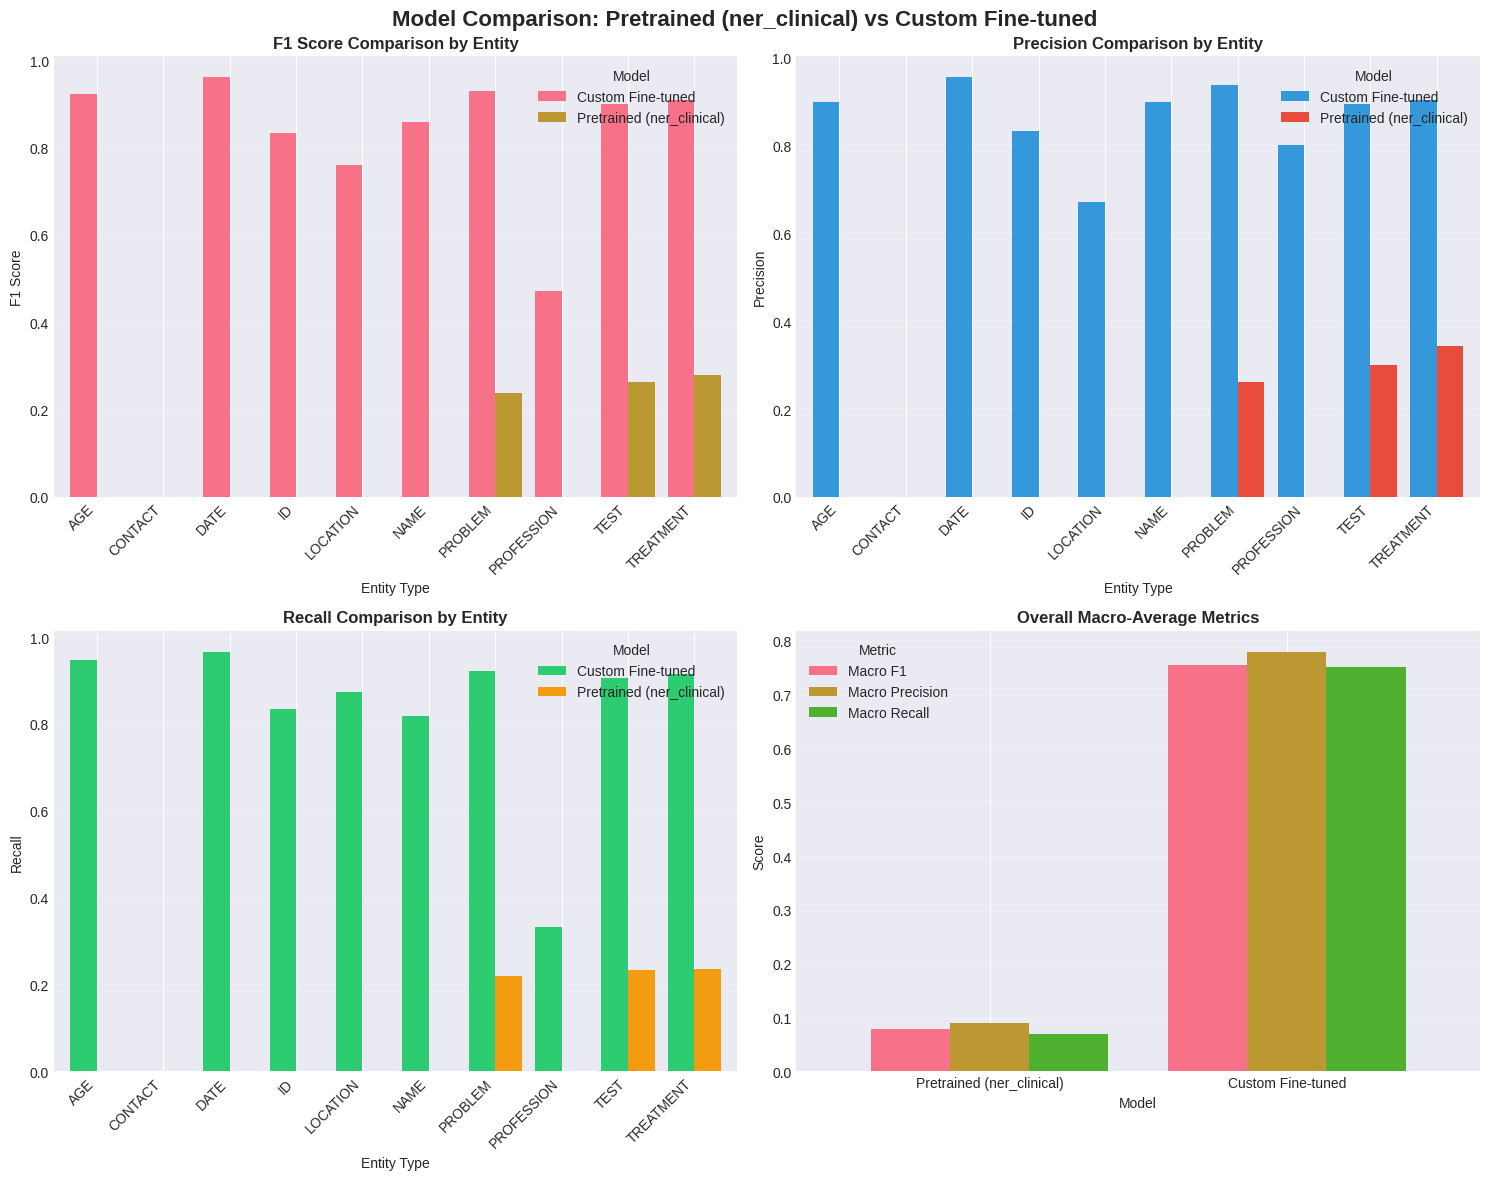


COMPARISON SUMMARY

Pretrained (ner_clinical):
  Macro F1: 0.0781
  Macro Precision: 0.0904
  Macro Recall: 0.0689

Custom Fine-tuned:
  Macro F1: 0.7540
  Macro Precision: 0.7793
  Macro Recall: 0.7511

✅ Model comparison completed!

Key Insights:
  ✅ Custom model improved F1 by 0.6759


In [22]:
# Compare pretrained model vs custom trained model
from pathlib import Path

# Load pretrained model (baseline)
pretrained_model = MedicalNerModel.pretrained("ner_clinical", "en", "clinical/models")\
    .setInputCols(["document", "token", "embeddings"])\
    .setOutputCol("ner")

# Load custom trained model
trained_model_path = f"{PROJECT_FOLDER}/models/trained/custom_ner_model"
if Path(trained_model_path).exists():
    custom_model = MedicalNerModel.load(trained_model_path)\
        .setInputCols(["document", "token", "embeddings"])\
        .setOutputCol("ner")

    print("Comparing models...")
    print("  - Baseline: ner_clinical (pretrained)")
    print("  - Custom: Fine-tuned model on your data")

    # Perform comparison
    comparison_results = visualizer.compare_models(
        model1=pretrained_model,
        model1_name="Pretrained (ner_clinical)",
        model2=custom_model,
        model2_name="Custom Fine-tuned",
        test_data=validation_data,
        embeddings_model=clinical_embeddings
    )

    print("\n✅ Model comparison completed!")
    print("\nKey Insights:")
    improvement = comparison_results[comparison_results['Model']=='Custom Fine-tuned']['F1'].mean() - \
                  comparison_results[comparison_results['Model']=='Pretrained (ner_clinical)']['F1'].mean()
    if improvement > 0:
        print(f"  ✅ Custom model improved F1 by {improvement:.4f}")
    else:
        print(f"  ⚠️  Custom model F1 decreased by {abs(improvement):.4f}")
        print("     Consider: more training data, hyperparameter tuning, or more epochs")
else:
    print("⚠️  Trained model not found. Please train the model first (Section 6).")


## 8.4 Error Analysis: Identify Common Mistakes

Perform detailed error analysis to identify patterns in misclassifications and improve the model.


Performing error analysis on custom trained model...
This may take a few minutes...
Performing error analysis...
  Using existing tokenized data...
  Using chunk-based analysis...


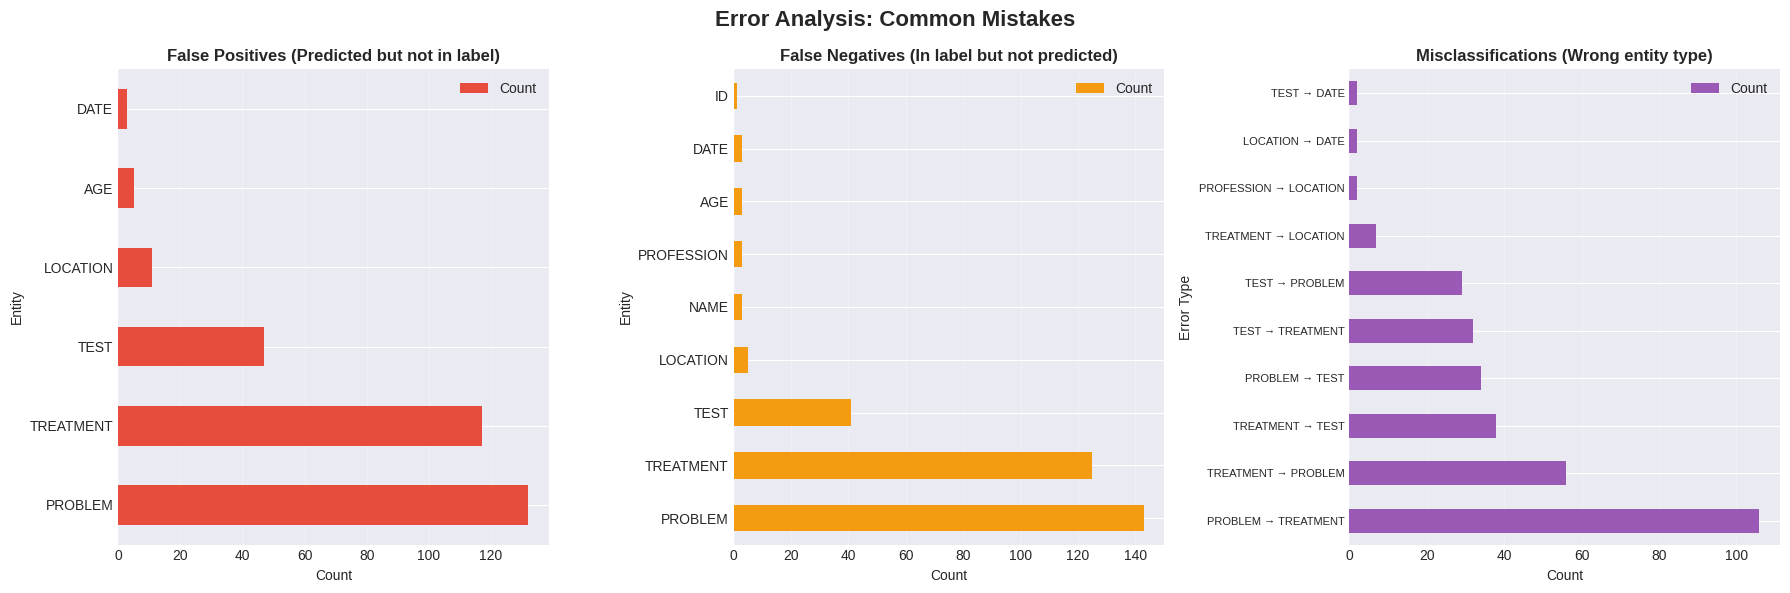


TOP ERROR EXAMPLES

🔴 False Positives (Top 5):
  PROBLEM: [('melanosis co', 2), ('sympto', 2), ('pa', 2)]
  TREATMENT: [('0.5% Marcai', 4), ('1:1 mixture of 0.5% Marcai', 2), ('1% lidocaine pla', 2)]
  AGE: [('7', 1), ('1-year-10-month-o', 1), ('4.5', 1)]
  LOCATION: [('contrast , Deutsch et', 1), ('9 o', 1), ('Retired Dock Ha', 1)]
  TEST: [('biopsi', 2), ('needle coun', 2), ('Monitor hemoglob', 1)]

🟡 False Negatives (Top 5):
  PROBLEM: [('complicatio', 3), ('Her symptoms of right greater than left upper extremity pa', 2), ('exacerbated her conditio', 2)]
  TEST: [('brachioradial', 2), ('Sponge , instrument and needle coun', 2), ('Album', 1)]
  TREATMENT: [('Vicr', 5), ('Marcai', 4), ('Vicryl sutur', 2)]
  ID: [('EC3870', 1)]
  NAME: [('X . Aga', 1), ('RIGHT ANKLE CLINICAL:Th', 1), ('Mark M . Musgra', 1)]

🟣 Misclassifications (Top 5):
  TEST → PROBLEM: [('last pap sme', 1), ('a positive ultrasou', 1), ('PCF-16', 1)]
  PROBLEM → TREATMENT: [('the bo', 2), ('retracti', 2), ('blunt di

In [23]:
# Perform error analysis on custom trained model
from pathlib import Path

trained_model_path = f"{PROJECT_FOLDER}/models/trained/custom_ner_model"
if Path(trained_model_path).exists():
    custom_model = MedicalNerModel.load(trained_model_path)\
        .setInputCols(["document", "token", "embeddings"])\
        .setOutputCol("ner")

    print("Performing error analysis on custom trained model...")
    print("This may take a few minutes...")

    # Run error analysis
    error_results = visualizer.error_analysis(
        model=custom_model,
        test_data=validation_data,
        embeddings_model=clinical_embeddings,
        top_errors=10
    )

    print("\n✅ Error analysis completed!")
    print("\n💡 Recommendations based on error analysis:")

    # Analyze errors and provide recommendations
    total_fp = sum(len(v) for v in error_results['false_positives'].values())
    total_fn = sum(len(v) for v in error_results['false_negatives'].values())
    total_mis = sum(len(v) for v in error_results['misclassifications'].values())

    print(f"\n  Total Errors:")
    print(f"    - False Positives: {total_fp}")
    print(f"    - False Negatives: {total_fn}")
    print(f"    - Misclassifications: {total_mis}")

    # Show top error entities (filter out 'O' if it appears)
    if error_results['false_positives']:
        print(f"\n  🔴 Top False Positive Entities:")
        fp_sorted = sorted(error_results['false_positives'].items(),
                          key=lambda x: len(x[1]), reverse=True)
        # Filter out 'O' entity type
        fp_sorted = [(e, ex) for e, ex in fp_sorted if e != 'O'][:5]
        for entity, examples in fp_sorted:
            print(f"     - {entity}: {len(examples)} errors")
            if examples:
                unique_examples = list(set(examples))[:3]  # Show unique examples
                print(f"       Examples: {unique_examples}")

    if error_results['false_negatives']:
        print(f"\n  🟡 Top False Negative Entities:")
        fn_sorted = sorted(error_results['false_negatives'].items(),
                          key=lambda x: len(x[1]), reverse=True)
        # Filter out 'O' entity type
        fn_sorted = [(e, ex) for e, ex in fn_sorted if e != 'O'][:5]
        for entity, examples in fn_sorted:
            print(f"     - {entity}: {len(examples)} errors")
            if examples:
                unique_examples = list(set(examples))[:3]  # Show unique examples
                print(f"       Examples: {unique_examples}")

    if error_results['misclassifications']:
        print(f"\n  🟣 Top Misclassifications:")
        mis_sorted = sorted(error_results['misclassifications'].items(),
                           key=lambda x: len(x[1]), reverse=True)[:5]
        for error_type, examples in mis_sorted:
            print(f"     - {error_type}: {len(examples)} errors")
            if examples:
                unique_examples = list(set(examples))[:3]  # Show unique examples
                print(f"       Examples: {unique_examples}")
    else:
        print(f"\n  ✅ No misclassifications found")

    # Recommendations
    if total_fp > total_fn:
        print("\n  📌 More False Positives detected:")
        print("     → Model is too aggressive in predictions")
        print("     → Consider: Increase confidence threshold, add more negative examples")
        print("     → Action: Review FP entities above and add negative training examples")
    elif total_fn > total_fp:
        print("\n  📌 More False Negatives detected:")
        print("     → Model is too conservative")
        print("     → Consider: More training data, lower confidence threshold")
        print("     → Action: Review FN entities above and add more training examples")
        print("     → Specific actions:")
        if error_results['false_negatives']:
            fn_entities = sorted(error_results['false_negatives'].items(),
                               key=lambda x: len(x[1]), reverse=True)[:3]
            for entity, _ in fn_entities:
                if entity != 'O':
                    print(f"        - Add more {entity} examples to training data")

    if total_mis > 0:
        print("\n  📌 Misclassifications found:")
        print("     → Model confuses between entity types")
        print("     → Action: Add more training examples for confused entity pairs shown above")
    else:
        print("\n  ✅ No misclassifications found - model correctly identifies entity boundaries")

    # Additional insights
    print(f"\n  📊 Error Distribution:")
    if error_results['false_positives']:
        fp_entities = [e for e in error_results['false_positives'].keys() if e != 'O']
        print(f"     - FP affects {len(fp_entities)} entity types")
    if error_results['false_negatives']:
        fn_entities = [e for e in error_results['false_negatives'].keys() if e != 'O']
        print(f"     - FN affects {len(fn_entities)} entity types")

else:
    print("⚠️  Trained model not found. Please train the model first (Section 6).")


## 8.5 Additional Visualizations: Training Progress

Visualize training progress from training logs.


Analyzing training log: ./ner_logs/MedicalNerApproach_efc523690338.log


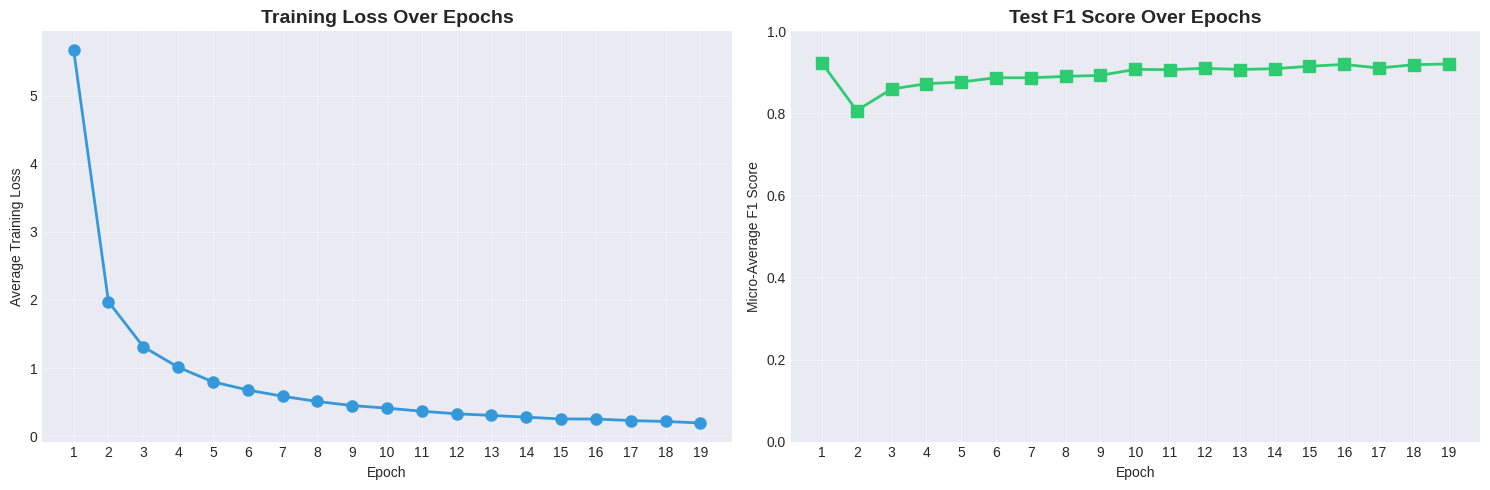

✅ Training progress visualized

📊 Parsed 19 epochs with training loss data
🏆 Best F1 Score: 0.9230 at epoch 1


In [24]:
# Visualize training progress from logs
import glob
import re

log_files = glob.glob("./ner_logs/MedicalNerApproach*")
if log_files:
    latest_log = max(log_files, key=os.path.getctime)
    print(f"Analyzing training log: {latest_log}")

    # Parse training log
    epochs = []
    train_losses = []
    test_f1_scores = []

    with open(latest_log, 'r') as f:
        content = f.read()

        # Extract epoch information - try to match epoch and loss together
        # Pattern 1: Epoch X/Y followed by loss on same or next line
        epoch_loss_pattern = r'Epoch (\d+)/(\d+).*?avg training loss: ([\d.]+)'
        epoch_loss_matches = re.findall(epoch_loss_pattern, content, re.DOTALL)

        # Pattern 2: F1 scores
        f1_pattern = r'Micro-average.*f1: ([\d.]+)'
        f1_found = re.findall(f1_pattern, content)

        # Extract epochs and losses that are paired together
        for epoch, total, loss in epoch_loss_matches:
            epoch_num = int(epoch)
            if epoch_num not in epochs:  # Avoid duplicates
                epochs.append(epoch_num)
                train_losses.append(float(loss))

        # Extract F1 scores - match with epochs if possible
        # Try to find epoch numbers near F1 scores
        f1_with_epoch_pattern = r'Epoch (\d+)/(\d+).*?Micro-average.*f1: ([\d.]+)'
        f1_with_epoch = re.findall(f1_with_epoch_pattern, content, re.DOTALL)

        # Create a mapping of epoch to F1 score
        epoch_to_f1 = {}
        for epoch, total, f1 in f1_with_epoch:
            epoch_num = int(epoch)
            if epoch_num not in epoch_to_f1:
                epoch_to_f1[epoch_num] = float(f1)

        # Match F1 scores with epochs we have
        for epoch in epochs:
            if epoch in epoch_to_f1:
                test_f1_scores.append(epoch_to_f1[epoch])
            elif len(test_f1_scores) < len(f1_found):
                # Fallback: use F1 scores in order if available
                test_f1_scores.append(float(f1_found[len(test_f1_scores)]))

        # Ensure all lists have the same length for epochs that have losses
        # Only keep epochs that have corresponding loss values
        if len(epochs) != len(train_losses):
            # This shouldn't happen with the new parsing, but just in case
            min_len = min(len(epochs), len(train_losses))
            epochs = epochs[:min_len]
            train_losses = train_losses[:min_len]

    if epochs and train_losses:
        # Ensure all lists have matching lengths
        min_len = min(len(epochs), len(train_losses))
        epochs_plot = epochs[:min_len]
        train_losses_plot = train_losses[:min_len]

        # Create visualization
        num_plots = 1 + (1 if test_f1_scores else 0)
        fig, axes = plt.subplots(1, num_plots, figsize=(15, 5))
        if num_plots == 1:
            axes = [axes]

        # Training Loss
        ax1 = axes[0]
        ax1.plot(epochs_plot, train_losses_plot, marker='o', linewidth=2, markersize=8, color='#3498db')
        ax1.set_title('Training Loss Over Epochs', fontweight='bold', fontsize=14)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Average Training Loss')
        ax1.grid(True, alpha=0.3)
        ax1.set_xticks(epochs_plot)

        # Test F1 Score
        if test_f1_scores:
            ax2 = axes[1]
            # Match F1 scores with epochs
            f1_epochs = epochs_plot[:len(test_f1_scores)]
            f1_scores_plot = test_f1_scores[:len(f1_epochs)]
            ax2.plot(f1_epochs, f1_scores_plot, marker='s', linewidth=2, markersize=8, color='#2ecc71')
            ax2.set_title('Test F1 Score Over Epochs', fontweight='bold', fontsize=14)
            ax2.set_xlabel('Epoch')
            ax2.set_ylabel('Micro-Average F1 Score')
            ax2.grid(True, alpha=0.3)
            ax2.set_xticks(f1_epochs)
            ax2.set_ylim([0, 1])

        plt.tight_layout()
        plt.show()

        print("✅ Training progress visualized")
        print(f"\n📊 Parsed {len(epochs_plot)} epochs with training loss data")
        if test_f1_scores:
            best_f1 = max(test_f1_scores)
            best_epoch_idx = test_f1_scores.index(best_f1)
            best_epoch = epochs_plot[best_epoch_idx] if best_epoch_idx < len(epochs_plot) else epochs_plot[0]
            print(f"🏆 Best F1 Score: {best_f1:.4f} at epoch {best_epoch}")
    elif epochs:
        print(f"⚠️  Found {len(epochs)} epochs but no training loss data. Log format may be different.")
    else:
        print("⚠️  Could not parse training log format")
else:
    print("⚠️  No training logs found. Please train the model first (Section 6).")
